In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/synthetic_fraud_dataset.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
# Generate UPI IDs (from previous notebook state)
banks = ["icici", "sbi", "hdfc", "axis", "kotak", "pnb", "boi"]
base_names = df['Merchant_Category'].str.replace(" ", "").str.lower()
numbers = np.random.randint(100, 999, size=len(df))
bank_names = np.random.choice(banks, size=len(df))
df['Merchant_UPI_ID'] = base_names + numbers.astype(str) + "@" + bank_names

# Reorder columns → insert after Merchant_Category
cols = df.columns.tolist()
insert_at = cols.index("Merchant_Category") + 1
cols = cols[:insert_at] + ["Merchant_UPI_ID"] + cols[insert_at:-1] + [cols[-1]]
df = df[cols]

# Drop duplicate columns if any
df = df.loc[:, ~df.columns.duplicated()]

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)

display(df.head())

Shape of dataset: (50000, 22)

Column names:
 Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'Merchant_UPI_ID', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type',
       'Card_Age', 'Transaction_Distance', 'Authentication_Method',
       'Risk_Score', 'Is_Weekend', 'Fraud_Label'],
      dtype='object')


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,Merchant_UPI_ID,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,travel318@boi,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,clothing214@axis,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,restaurants398@sbi,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,clothing292@sbi,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,electronics889@kotak,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


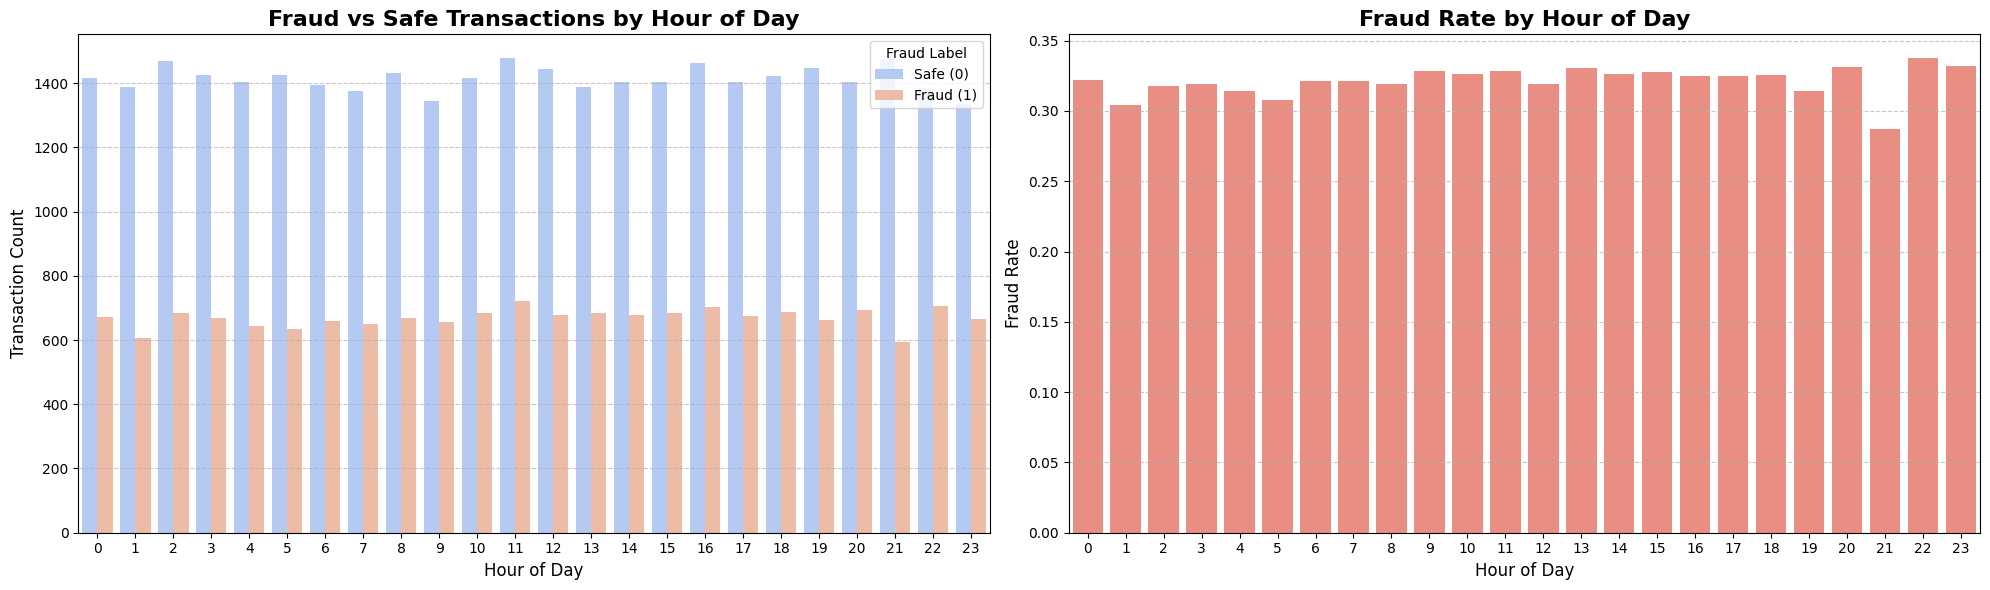

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract hour from Timestamp
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour

# Create a figure with 2 subplots in a row
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,6))

# --- Left plot: Fraud by Hour of Day ---
sns.countplot(x='Hour', hue='Fraud_Label', data=df, palette="coolwarm", ax=axes[0])
axes[0].set_title("Fraud vs Safe Transactions by Hour of Day", fontsize=16, weight='bold')
axes[0].set_xlabel("Hour of Day", fontsize=12)
axes[0].set_ylabel("Transaction Count", fontsize=12)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].legend(title="Fraud Label", labels=["Safe (0)", "Fraud (1)"], fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Right plot: Fraud rate by hour (same color bars, no top line) ---
sns.barplot(
    x='Hour',
    y='Fraud_Label',
    data=df,
    estimator=lambda x: sum(x)/len(x),
    color='salmon',
    ax=axes[1],
    errorbar=None
)
axes[1].set_title("Fraud Rate by Hour of Day", fontsize=16, weight='bold')
axes[1].set_xlabel("Hour of Day", fontsize=12)
axes[1].set_ylabel("Fraud Rate", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


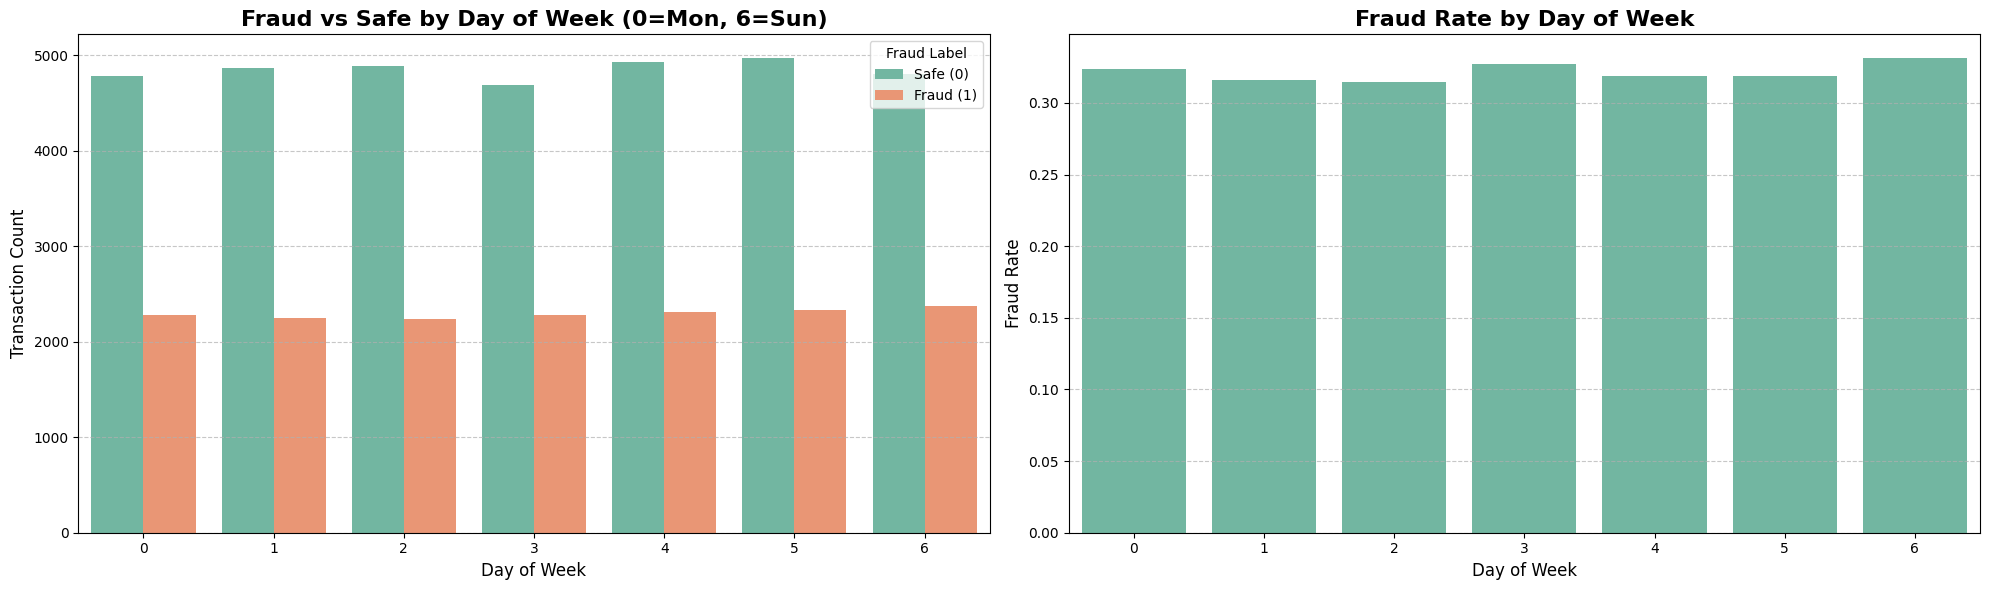

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract Day of Week from Timestamp
df['DayOfWeek'] = pd.to_datetime(df['Timestamp']).dt.dayofweek

# Create a figure with 2 subplots in a row
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,6))

# --- Left plot: Fraud by Day of Week ---
sns.countplot(
    x='DayOfWeek',
    hue='Fraud_Label',
    data=df,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Fraud vs Safe by Day of Week (0=Mon, 6=Sun)", fontsize=16, weight='bold')
axes[0].set_xlabel("Day of Week", fontsize=12)
axes[0].set_ylabel("Transaction Count", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title="Fraud Label", labels=["Safe (0)", "Fraud (1)"], fontsize=10)

# --- Right plot: Fraud rate by Day of Week (same color for all bars) ---
sns.barplot(
    x='DayOfWeek',
    y='Fraud_Label',
    data=df,
    estimator=lambda x: sum(x)/len(x),
    color="#66c2a5",     # 👈 Same color for all bars
    ax=axes[1],
    errorbar=None        # 👈 Removes the top confidence lines
)
axes[1].set_title("Fraud Rate by Day of Week", fontsize=16, weight='bold')
axes[1].set_xlabel("Day of Week", fontsize=12)
axes[1].set_ylabel("Fraud Rate", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


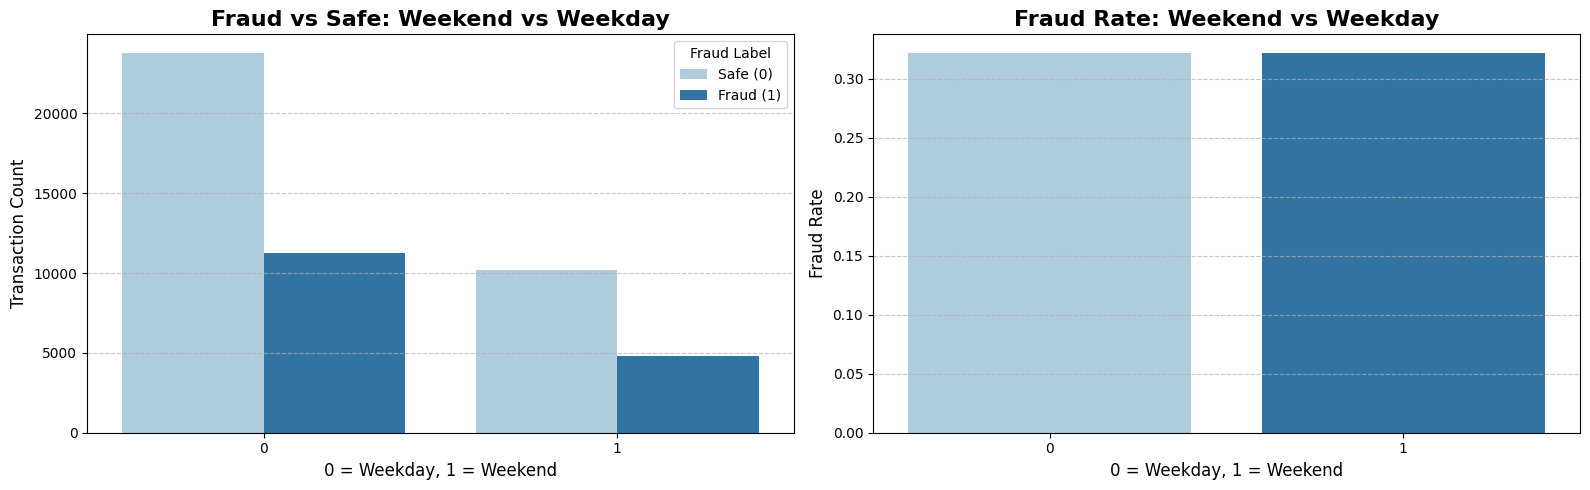

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2 subplots in a row
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,5))

# --- Left plot: Fraud by Weekend vs Weekday ---
sns.countplot(
    x='Is_Weekend',
    hue='Fraud_Label',
    data=df,
    palette="Paired",
    ax=axes[0]
)
axes[0].set_title("Fraud vs Safe: Weekend vs Weekday", fontsize=16, weight='bold')
axes[0].set_xlabel("0 = Weekday, 1 = Weekend", fontsize=12)
axes[0].set_ylabel("Transaction Count", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title="Fraud Label", labels=["Safe (0)", "Fraud (1)"], fontsize=10)

# --- Right plot: Fraud rate by Weekend/Weekday (no top line) ---
sns.barplot(
    x='Is_Weekend',
    y='Fraud_Label',
    data=df,
    estimator=lambda x: sum(x)/len(x),
    palette="Paired",
    ax=axes[1],
    hue='Is_Weekend',
    legend=False,
    errorbar=None  # 👈 Removes confidence interval lines
)
axes[1].set_title("Fraud Rate: Weekend vs Weekday", fontsize=16, weight='bold')
axes[1].set_xlabel("0 = Weekday, 1 = Weekend", fontsize=12)
axes[1].set_ylabel("Fraud Rate", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


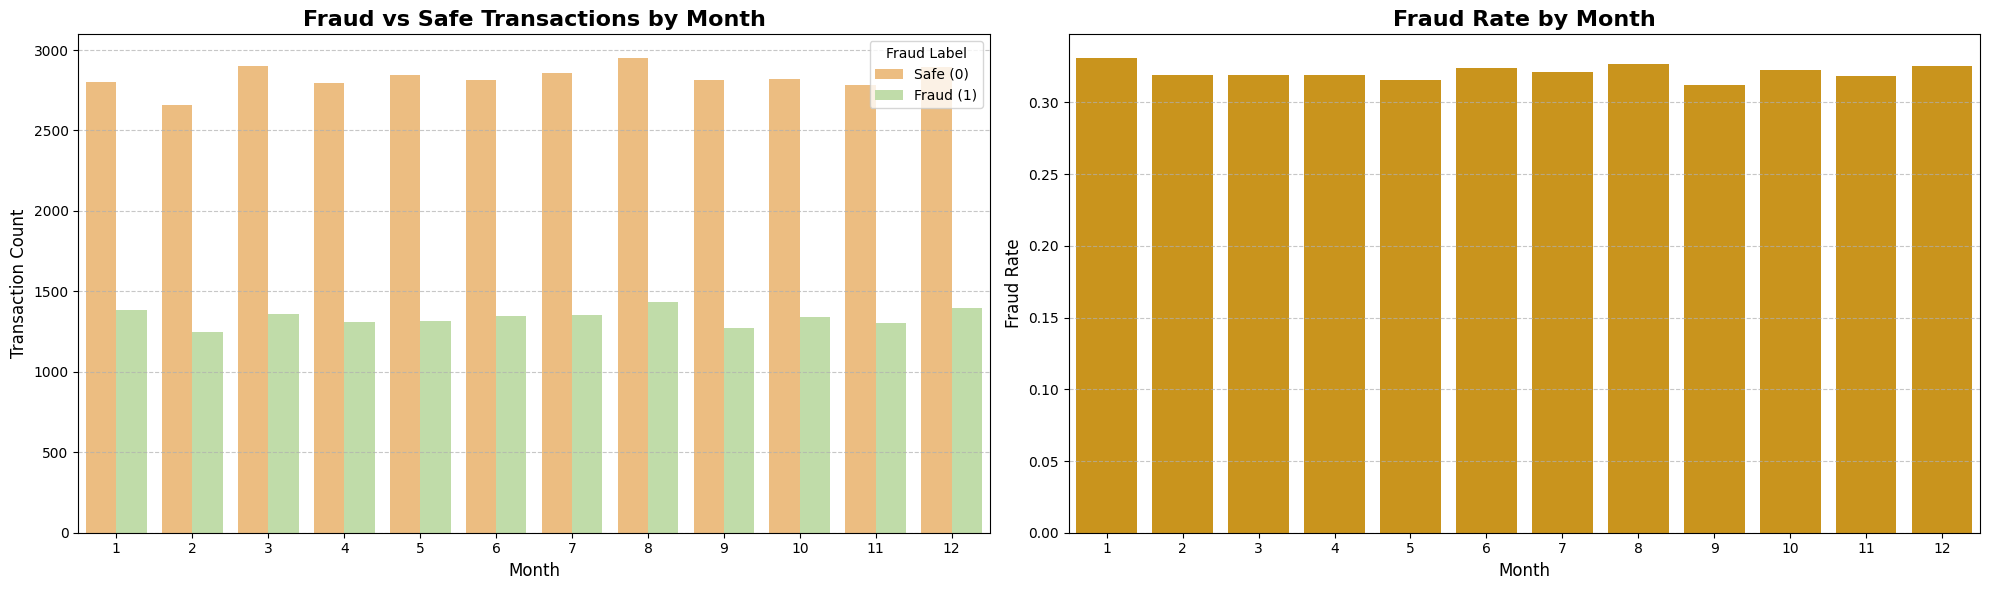

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract Month from Timestamp
df['Month'] = pd.to_datetime(df['Timestamp']).dt.month

# Create a figure with 2 subplots in a row
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,6))

# --- Left plot: Fraud by Month ---
sns.countplot(
    x='Month',
    hue='Fraud_Label',
    data=df,
    palette="Spectral",
    ax=axes[0]
)
axes[0].set_title("Fraud vs Safe Transactions by Month", fontsize=16, weight='bold')
axes[0].set_xlabel("Month", fontsize=12)
axes[0].set_ylabel("Transaction Count", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title="Fraud Label", labels=["Safe (0)", "Fraud (1)"], fontsize=10)

# --- Right plot: Fraud rate by Month (same color for all bars) ---
sns.barplot(
    x='Month',
    y='Fraud_Label',
    data=df,
    estimator=lambda x: sum(x)/len(x),
    color="#E69F00",     # 👈 Same color for all bars (you can change this)
    ax=axes[1],
    errorbar=None        # 👈 Removes top confidence lines
)
axes[1].set_title("Fraud Rate by Month", fontsize=16, weight='bold')
axes[1].set_xlabel("Month", fontsize=12)
axes[1].set_ylabel("Fraud Rate", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
